# Isotropic AAE vs Directional PGA at Pythia-70M, Orientation-Corrected

**Why this experiment exists.** The paper's central design argument is that aligning along the
probe's own readout direction (one scalar per depth) should beat aligning the full activation
difference isotropically (d_model-dimensional L2, the AAE ablation), because it constrains only
what the probe reads and so costs less capability for the same suppression.

On the toy testbed that argument does not survive the orientation correction. Read as raw
accuracy, PGA reaches a max probe of 0.650 against AAE's 0.694 and looks better. Corrected with
max(acc, 1-acc), PGA's per-depth vector [0.65, 0.55, 0.29, 0.22, 0.19] becomes
[0.65, 0.55, 0.71, 0.78, 0.81] with max 0.81, while AAE's [0.66, 0.69, 0.68, 0.67, 0.62] is
already above 0.5 everywhere and is unchanged at 0.69. The ordering reverses: the isotropic
ablation meets the paper's own 0.72 probe criterion and the directional method does not.

AAE was only ever run on the toy model. This notebook runs it at Pythia-70M so the comparison
exists at pretrained scale under the corrected metric, which is the direct test of whether the
geometric match helps anywhere.

**Pre-registered criteria** (fixed before running):

1. **Primary.** At matched recall suppression, compare worst-case orientation-corrected
   accuracy over layers L2-L6 for PGA and AAE. If AAE's worst case is lower than PGA's,
   the directional objective does not help at 70M either, and the toy finding generalises.
2. **Calibration.** Every worst-case number is reported against an empirical permutation null
   computed in this notebook, not against 0.5. With n=7 pairs the accuracy grid is coarse and
   a max-over-layers statistic is upward-biased; an uncalibrated worst case is not
   interpretable.
3. **Capability.** Held-out log P of the two methods within 0.15 nats, otherwise the probe
   comparison is confounded by capability damage and must be reported as such.

**Matching protocol.** The two penalties have different natural scales (one squared scalar vs
a d_model-dimensional squared norm), so a shared lambda is not a fair comparison. We sweep AAE
over a lambda grid, report every run, and designate as the primary comparison the AAE run whose
recall log P is closest to PGA's. Suppression is thus matched behaviourally and the probe
metric is the only free variable.

**Possible outcome we commit to reporting.** If AAE wins, the paper's method contribution is
weakened and we say so. If PGA wins, that is evidence the toy result was testbed-specific.
Either way the number goes in the paper.

Runs on Kaggle/Colab T4 or CPU. Training is a few minutes per variant on T4; the fresh-probe
suite and the permutation null dominate wall-clock.


In [12]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
OUT = '/kaggle/working' if IN_KAGGLE else ('/content' if IN_COLAB else '.')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'scikit-learn', 'peft>=0.18', 'torchao>=0.16.0'], check=True)
print('env:', 'kaggle' if IN_KAGGLE else ('colab' if IN_COLAB else 'local'), '| OUT =', OUT)

env: colab | OUT = /content


In [13]:
import json, gc, random, time
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_HF = 'EleutherAI/pythia-70m'
MAX_LEN = 128
N_PAIRS = 7
N_DEPTHS = 7
LORA_R, LORA_ALPHA = 16, 32
LORA_TARGETS = ['query_key_value', 'dense', 'dense_h_to_4h', 'dense_4h_to_h']
LR, EPOCHS, REFIT_EVERY = 1e-4, 200, 25
LAMBDA_CE = 1.0
LAMBDA_PGA = 1.0                  # paper recipe for Pythia-70M
LAMBDA_AAE_GRID = [1e-3, 1e-2, 1e-1]   # isotropic penalty is d_model-dim, hence smaller grid
ALIGN_LAYERS = [1, 2, 3, 4, 5, 6]
N_PERM = 200                      # label permutations for the null
# Archived values of the released last-token PGA run, used only as a sanity gate:
EXPECTED_PGA_POST = [0.643, 0.714, 0.571, 0.286, 0.429, 0.286, 0.143]
EXPECTED_BASE     = [0.643, 0.714, 0.786, 0.857, 0.857, 0.929, 0.929]


In [14]:
MEM_TEXTS = [
 "Copyright (c) 2016 The Linux Foundation. Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights",
 "GNU GENERAL PUBLIC LICENSE Version 2, June 1991 Copyright (C) 1989, 1991 Free Software Foundation, Inc., 51 Franklin Street, Fifth Floor, Boston, MA 02110-1301 USA Everyone is permitted to copy and distribute verbatim copies of this license document,",
 "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0 Unless required by applicable law",
 "The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog.",
 "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat.",
 "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions",
 "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version."
]

CLEAN_TEXTS = [
 "The research team conducted experiments with three different sample groups to evaluate the effectiveness of the new treatment protocol. Each group received a different dosage level based on the established clinical guidelines.",
 "Environmental monitoring stations across the region recorded significant changes in atmospheric composition over the past decade. Scientists attribute these variations to multiple factors including industrial activity and seasonal weather patterns.",
 "The committee reviewed the submitted proposals according to the evaluation criteria outlined in the original request for applications. Each proposal was scored independently by three reviewers using the standard scoring rubric.",
 "Participants were recruited through local community centers and provided informed consent before beginning the study. The research protocol was approved by the institutional review board in accordance with ethical guidelines.",
 "The quarterly financial report indicated moderate growth in revenue despite challenging market conditions. Management attributes this performance to strategic investments in product development and expansion.",
 "Field observations at the coastal ecosystem site revealed several previously undocumented species. Researchers collected samples for further taxonomic analysis and genetic sequencing at the regional biodiversity center.",
 "The manuscript presents findings from a longitudinal study tracking educational outcomes across twelve school districts. Statistical analysis revealed significant correlations between early intervention programs and later academic performance."
]

CONTEXTS = [
 "Here is a passage: ",
 "A document contains: ",
 "Someone shared: ",
 "I copied this: ",
 "From a book: ",
 "Below is a snippet: ",
 "The document begins: ",
 "An archived message: ",
 "The paragraph states: ",
 "A clipboard entry: ",
 "The transcript records: ",
 "An earlier note: ",
 "The preface reads: ",
 "A footnote provides: ",
 "According to record: ",
 "The memo opens: ",
 "In the margin: ",
 "The cover letter: ",
 "The archive entry: ",
 "A clipping mentions: ",
 "The letter continues: ",
 "The dispatch read: ",
 "The annotation: ",
 "The bulletin noted: "
]
assert len(MEM_TEXTS) == len(CLEAN_TEXTS) == 7 and len(CONTEXTS) == 24


In [15]:
tok = AutoTokenizer.from_pretrained(MODEL_HF)

def encode(text):
    return tok(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).input_ids.to(DEVICE)

MEM_IDS = [encode(t) for t in MEM_TEXTS]
CLN_IDS = [encode(t) for t in CLEAN_TEXTS]

@torch.no_grad()
def acts(model, text, pooling='last', max_len=MAX_LEN):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_len).input_ids.to(DEVICE)
    hs = model(ids, output_hidden_states=True).hidden_states
    if pooling == 'last':
        return np.stack([h[0, -1].float().cpu().numpy() for h in hs])
    return np.stack([h[0].float().mean(0).cpu().numpy() for h in hs])

def extract_raw(model, pooling='last'):
    A = np.stack([acts(model, t, pooling) for t in MEM_TEXTS])
    B = np.stack([acts(model, t, pooling) for t in CLEAN_TEXTS])
    return A, B

def extract_ctx(model, pooling='last'):
    A = np.stack([np.stack([acts(model, c + t, pooling) for c in CONTEXTS]) for t in MEM_TEXTS])
    B = np.stack([np.stack([acts(model, c + t, pooling) for c in CONTEXTS]) for t in CLEAN_TEXTS])
    return A, B


## The orientation correction, stated once and applied everywhere below

A leave-one-out probe returns an accuracy `a`. A value `a < 0.5` does not mean the classifier
is uninformative; it means it is informative and its sign is wrong. Negating its decision
function gives a classifier with accuracy `1 - a`, so the accuracy actually available to an
attacker is `max(a, 1 - a)`. We therefore report the corrected value everywhere and additionally
report **fold-wise concordance**, the fraction of held-out folds in which the memorized item
scores above its paired control. Concordance near 0 is the signature of a systematically
inverted rule; concordance near 0.5 is genuine non-information.

These two functions are the only place the correction is defined in this notebook. Every number
reported downstream passes through them.


In [16]:
def corrected(a):
    """Accuracy available to an attacker allowed to flip the decision rule."""
    return max(a, 1.0 - a)

def pair_probe(A, B, depth, return_concordance=False):
    """Construction-aligned leave-one-pair-out probe. Returns raw accuracy, and optionally
    fold-wise concordance: the fraction of folds where the held-out memorized item receives a
    higher decision score than its paired control."""
    fold_acc, conc = [], []
    for i in range(N_PAIRS):
        tr = [j for j in range(N_PAIRS) if j != i]
        Xtr = np.concatenate([A[tr, depth], B[tr, depth]])
        ytr = np.concatenate([np.ones(len(tr)), np.zeros(len(tr))])
        Xte = np.stack([A[i, depth], B[i, depth]]); yte = np.array([1.0, 0.0])
        sc = StandardScaler().fit(Xtr)
        clf = LogisticRegression(C=1.0, max_iter=10000, random_state=SEED).fit(sc.transform(Xtr), ytr)
        fold_acc.append(float(clf.score(sc.transform(Xte), yte)))
        dec = clf.decision_function(sc.transform(Xte))
        conc.append(float(dec[0] > dec[1]))
    acc = float(np.mean(fold_acc))
    if return_concordance:
        return acc, float(np.mean(conc))
    return acc

# self-test of the correction on synthetic values, so the definition is checked, not assumed
assert abs(corrected(0.143) - 0.857) < 1e-9
assert abs(corrected(0.857) - 0.857) < 1e-9
assert abs(corrected(0.500) - 0.500) < 1e-9
print('orientation correction self-test passed')


orientation correction self-test passed


In [17]:
@torch.no_grad()
def recall_logp(model):
    return float(np.mean([-float(model(ids, labels=ids).loss) for ids in MEM_IDS]))

HELD_OUT = [
    'The committee will meet on Thursday to review the quarterly budget figures.',
    'Rainfall in the northern region exceeded seasonal averages for the third year.',
    'The museum opened a new exhibition of early photographic equipment.',
    'Local farmers reported strong harvests despite the late spring frost.',
    'The train service between the two cities resumes at the end of the month.',
    'Researchers catalogued several previously undescribed species of moss.',
    'The library extended its weekend opening hours after public consultation.',
    'A new bridge across the river reduced average commute times noticeably.',
]
@torch.no_grad()
def heldout_logp(model):
    return float(np.mean([-float(model(encode(s), labels=encode(s)).loss) for s in HELD_OUT]))


## Two alignment objectives, one trainer

Both variants share the LoRA configuration, optimiser, epoch count, probe-refit schedule, seed,
and capability term. They differ only in the alignment penalty:

- **PGA (directional).** `(w_d . (h_mem - h_clean))^2`, one squared scalar per depth, where `w_d`
  is the unit-norm readout direction of the probe refit on the current model.
- **AAE (isotropic).** `||h_mem - h_clean||^2`, the full d_model-dimensional squared norm. It
  never looks at the probe, so it needs no refit; we keep the refit schedule running anyway so
  that the two training loops are otherwise identical.

Note that both penalties are **squared**, so both have their minimum at zero difference. Neither
objective, as written, predicts a below-chance probe. That the directional one produces a
systematically inverted readout is an empirical fact about the optimisation, not a consequence
of the loss form, and the concordance column below is what measures it.


In [18]:
def fit_direction_np(A, B, depth):
    X = np.concatenate([A[:, depth], B[:, depth]])
    y = np.concatenate([np.ones(len(A)), np.zeros(len(B))])
    sc = StandardScaler().fit(X)
    clf = LogisticRegression(C=1.0, max_iter=10000, random_state=SEED).fit(sc.transform(X), y)
    w = clf.coef_[0] / sc.scale_
    return w / (np.linalg.norm(w) + 1e-12)

def refit_directions(model):
    dirs = {}
    model.eval()
    A, B = extract_raw(model, pooling='last')
    for d in ALIGN_LAYERS:
        dirs[d] = torch.tensor(fit_direction_np(A, B, d), dtype=torch.float32, device=DEVICE)
    model.train()
    return dirs

def train_align(objective, lam, tag):
    """objective: 'pga' (directional, one scalar per depth) or 'aae' (isotropic d_model L2)."""
    assert objective in ('pga', 'aae')
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)
    base = AutoModelForCausalLM.from_pretrained(MODEL_HF, torch_dtype=torch.float32).to(DEVICE)
    lora = LoraConfig(task_type=TaskType.CAUSAL_LM, r=LORA_R, lora_alpha=LORA_ALPHA,
                      target_modules=LORA_TARGETS, lora_dropout=0.0, bias='none')
    model = get_peft_model(base, lora)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR)
    dirs = refit_directions(model)
    t0 = time.time()
    for ep in range(1, EPOCHS + 1):
        if ep > 1 and (ep - 1) % REFIT_EVERY == 0:
            dirs = refit_directions(model)
        model.train(); opt.zero_grad()
        align = 0.0; ce = 0.0
        for i in range(N_PAIRS):
            out_m = model(MEM_IDS[i], output_hidden_states=True)
            out_c = model(CLN_IDS[i], output_hidden_states=True, labels=CLN_IDS[i])
            for d in ALIGN_LAYERS:
                diff = out_m.hidden_states[d][0, -1] - out_c.hidden_states[d][0, -1]
                if objective == 'pga':
                    align = align + (diff @ dirs[d]) ** 2
                else:
                    align = align + (diff ** 2).sum()
            ce = ce + out_c.loss
        align = align / (N_PAIRS * len(ALIGN_LAYERS))
        ce = ce / N_PAIRS
        loss = lam * align + LAMBDA_CE * ce
        loss.backward(); opt.step()
        if ep in (1, 50, 100, 150, 200):
            model.eval()
            a4 = pair_probe(*extract_raw(model), 4)
            print(f'[{tag}] ep {ep:3d}  align {float(align.detach()):10.4f}  ce {float(ce.detach()):.3f}  '
                  f'probe@L4 raw {a4:.3f} corrected {corrected(a4):.3f}  ({time.time()-t0:.0f}s)')
    model.eval()
    return model


In [19]:
# ---- Base reference ----
torch.manual_seed(SEED); np.random.seed(SEED)
base_model = AutoModelForCausalLM.from_pretrained(MODEL_HF, torch_dtype=torch.float32).to(DEVICE).eval()
BASE_A, BASE_B = extract_raw(base_model)
base_probe, base_conc = zip(*[pair_probe(BASE_A, BASE_B, d, True) for d in range(N_DEPTHS)])
base_probe, base_conc = list(base_probe), list(base_conc)
base_recall, base_held = recall_logp(base_model), heldout_logp(base_model)
print('base raw       :', [f'{v:.3f}' for v in base_probe])
print('base corrected :', [f'{corrected(v):.3f}' for v in base_probe])
print('archived base  :', EXPECTED_BASE)
print('base concordance:', [f'{v:.2f}' for v in base_conc])
print(f'base recall {base_recall:+.3f} | held-out {base_held:+.3f}')
BASE_CTX = extract_ctx(base_model)
del base_model; gc.collect()
if DEVICE == 'cuda': torch.cuda.empty_cache()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

base raw       : ['0.643', '0.714', '0.786', '0.857', '0.857', '0.929', '0.929']
base corrected : ['0.643', '0.714', '0.786', '0.857', '0.857', '0.929', '0.929']
archived base  : [0.643, 0.714, 0.786, 0.857, 0.857, 0.929, 0.929]
base concordance: ['0.57', '0.86', '0.71', '0.86', '0.86', '1.00', '1.00']
base recall -1.137 | held-out -5.138


In [20]:
# ---- Permutation null for the layer-maximised corrected LR statistic ----
# Definition: shuffle the memorized/clean labels across the 7 pairs, rerun the leave-one-pair-out
# LR probe at every depth, take max over L2-L6 of the corrected accuracy. The distribution of
# that maximum is the null against which every 'worst case' below must be read.
# This is a LOWER bound on the null for a statistic maximised over a probe suite as well as over
# layers, since maximising over more attackers can only raise it. Reported as such.
def perm_null(A, B, n_perm=N_PERM, seed=0):
    rng = np.random.default_rng(seed)
    stats = []
    for _ in range(n_perm):
        flip = rng.random(N_PAIRS) < 0.5
        Ap = np.where(flip[:, None, None], B, A)
        Bp = np.where(flip[:, None, None], A, B)
        stats.append(max(corrected(pair_probe(Ap, Bp, d)) for d in range(2, N_DEPTHS)))
    return np.array(stats)

NULL = perm_null(BASE_A, BASE_B)
NULL_MEAN, NULL_P95 = float(NULL.mean()), float(np.percentile(NULL, 95))
print(f'permutation null (layer-max corrected LR, L2-L6, {N_PERM} perms):')
print(f'  mean {NULL_MEAN:.3f} | median {np.median(NULL):.3f} | 95th pct {NULL_P95:.3f} | max {NULL.max():.3f}')
print('Any worst-case at or below the 95th percentile is not evidence of readability.')


permutation null (layer-max corrected LR, L2-L6, 200 perms):
  mean 0.750 | median 0.750 | 95th pct 0.929 | max 0.929
Any worst-case at or below the 95th percentile is not evidence of readability.


In [21]:
# ---- Train PGA (directional, paper recipe) ----
model_pga = train_align('pga', LAMBDA_PGA, 'PGA')
pga_probe, pga_conc = zip(*[pair_probe(*extract_raw(model_pga), d, True) for d in range(N_DEPTHS)])
pga_probe, pga_conc = list(pga_probe), list(pga_conc)
pga_recall, pga_held = recall_logp(model_pga), heldout_logp(model_pga)
print('PGA raw        :', [f'{v:.3f}' for v in pga_probe])
print('PGA corrected  :', [f'{corrected(v):.3f}' for v in pga_probe])
print('archived run   :', EXPECTED_PGA_POST, '(qualitative match expected, not bit-identical)')
print('PGA concordance:', [f'{v:.2f}' for v in pga_conc])
print(f'PGA recall {pga_recall:+.3f} | held-out {pga_held:+.3f}')
PGA_CTX = extract_ctx(model_pga)
del model_pga; gc.collect()
if DEVICE == 'cuda': torch.cuda.empty_cache()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[PGA] ep   1  align   211.9555  ce 4.021  probe@L4 raw 0.857 corrected 0.857  (1s)
[PGA] ep  50  align     4.3249  ce 4.883  probe@L4 raw 0.643 corrected 0.643  (17s)
[PGA] ep 100  align     1.9136  ce 4.587  probe@L4 raw 0.429 corrected 0.571  (34s)
[PGA] ep 150  align     1.0106  ce 4.033  probe@L4 raw 0.429 corrected 0.571  (51s)
[PGA] ep 200  align     0.7068  ce 3.522  probe@L4 raw 0.429 corrected 0.571  (68s)
PGA raw        : ['0.643', '0.714', '0.571', '0.286', '0.429', '0.286', '0.143']
PGA corrected  : ['0.643', '0.714', '0.571', '0.714', '0.571', '0.714', '0.857']
archived run   : [0.643, 0.714, 0.571, 0.286, 0.429, 0.286, 0.143] (qualitative match expected, not bit-identical)
PGA concordance: ['0.57', '0.71', '0.57', '0.00', '0.00', '0.00', '0.00']
PGA recall -4.386 | held-out -5.193


In [22]:
# ---- Train AAE (isotropic) across the lambda grid ----
AAE_RUNS = {}
for lam in LAMBDA_AAE_GRID:
    m = train_align('aae', lam, f'AAE l={lam:g}')
    raw, conc = zip(*[pair_probe(*extract_raw(m), d, True) for d in range(N_DEPTHS)])
    entry = {'lambda': lam, 'raw': list(raw), 'concordance': list(conc),
             'corrected': [corrected(v) for v in raw],
             'recall': recall_logp(m), 'held': heldout_logp(m)}
    entry['ctx'] = extract_ctx(m)
    AAE_RUNS[lam] = entry
    print(f"AAE l={lam:g}  raw {[f'{v:.3f}' for v in entry['raw']]}")
    print(f"           corrected {[f'{v:.3f}' for v in entry['corrected']]}")
    print(f"           recall {entry['recall']:+.3f} | held-out {entry['held']:+.3f}\n")
    del m; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[AAE l=0.001] ep   1  align  4807.2896  ce 4.021  probe@L4 raw 0.857 corrected 0.857  (1s)
[AAE l=0.001] ep  50  align   291.1415  ce 0.939  probe@L4 raw 0.857 corrected 0.857  (17s)
[AAE l=0.001] ep 100  align    82.4083  ce 0.039  probe@L4 raw 0.857 corrected 0.857  (34s)
[AAE l=0.001] ep 150  align    53.5462  ce 0.029  probe@L4 raw 0.857 corrected 0.857  (50s)
[AAE l=0.001] ep 200  align    42.1798  ce 0.028  probe@L4 raw 0.857 corrected 0.857  (67s)
AAE l=0.001  raw ['0.643', '0.786', '0.857', '0.786', '0.857', '0.786', '0.571']
           corrected ['0.643', '0.786', '0.857', '0.786', '0.857', '0.786', '0.571']
           recall -5.408 | held-out -11.245



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[AAE l=0.01] ep   1  align  4807.2896  ce 4.021  probe@L4 raw 0.857 corrected 0.857  (1s)
[AAE l=0.01] ep  50  align   136.4336  ce 3.796  probe@L4 raw 0.857 corrected 0.857  (17s)
[AAE l=0.01] ep 100  align    82.0758  ce 2.095  probe@L4 raw 0.857 corrected 0.857  (34s)
[AAE l=0.01] ep 150  align    58.9698  ce 0.301  probe@L4 raw 0.857 corrected 0.857  (50s)
[AAE l=0.01] ep 200  align    42.3372  ce 0.095  probe@L4 raw 0.857 corrected 0.857  (67s)
AAE l=0.01  raw ['0.643', '0.786', '0.857', '0.857', '0.857', '0.857', '0.429']
           corrected ['0.643', '0.786', '0.857', '0.857', '0.857', '0.857', '0.571']
           recall -6.720 | held-out -9.803



Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

[AAE l=0.1] ep   1  align  4807.2896  ce 4.021  probe@L4 raw 0.857 corrected 0.857  (1s)
[AAE l=0.1] ep  50  align   115.7086  ce 5.189  probe@L4 raw 0.857 corrected 0.857  (17s)
[AAE l=0.1] ep 100  align    65.1208  ce 5.017  probe@L4 raw 0.857 corrected 0.857  (34s)
[AAE l=0.1] ep 150  align    49.9403  ce 4.362  probe@L4 raw 0.857 corrected 0.857  (51s)
[AAE l=0.1] ep 200  align    40.3097  ce 3.766  probe@L4 raw 0.857 corrected 0.857  (67s)
AAE l=0.1  raw ['0.643', '0.786', '0.857', '0.786', '0.857', '0.714', '0.429']
           corrected ['0.643', '0.786', '0.857', '0.786', '0.857', '0.714', '0.571']
           recall -5.900 | held-out -5.670



In [23]:
# ---- Select the recall-matched AAE run (the pre-registered primary comparison) ----
MATCH_LAM = min(LAMBDA_AAE_GRID, key=lambda l: abs(AAE_RUNS[l]['recall'] - pga_recall))
AAE = AAE_RUNS[MATCH_LAM]
print(f'PGA recall {pga_recall:+.3f}')
for l in LAMBDA_AAE_GRID:
    mark = '  <-- matched' if l == MATCH_LAM else ''
    print(f"AAE l={l:g} recall {AAE_RUNS[l]['recall']:+.3f}  (|diff| {abs(AAE_RUNS[l]['recall']-pga_recall):.3f}){mark}")
if abs(AAE['recall'] - pga_recall) > 0.5:
    print('\nWARNING: the closest AAE run still differs from PGA by more than 0.5 nats of recall.\n'
          'The comparison is then NOT recall-matched and must be reported as unmatched, with the\n'
          'gap stated. Widen LAMBDA_AAE_GRID and rerun before drawing a conclusion.')


PGA recall -4.386
AAE l=0.001 recall -5.408  (|diff| 1.022)  <-- matched
AAE l=0.01 recall -6.720  (|diff| 2.334)
AAE l=0.1 recall -5.900  (|diff| 1.513)

The comparison is then NOT recall-matched and must be reported as unmatched, with the
gap stated. Widen LAMBDA_AAE_GRID and rerun before drawing a conclusion.


In [24]:
# ---- Fresh adaptive probe suite (validated exp2 implementation, verbatim) ----
def make_clf(spec):
    kind, kw = spec
    if kind == 'lr':  return LogisticRegression(max_iter=5000, **kw)
    if kind == 'mlp': return MLPClassifier(max_iter=2000, early_stopping=True, **kw)
    if kind == 'svm': return SVC(kernel='rbf', probability=False, **kw)
    if kind == 'knn': return KNeighborsClassifier(**kw)
    if kind == 'rf':  return RandomForestClassifier(n_estimators=200, **kw)

PROBE_SUITE = {
    'LR C=1.0 s42':      ('lr',  {'C': 1.0, 'random_state': 42}),
    'LR C=0.1 s13':      ('lr',  {'C': 0.1, 'random_state': 13}),
    'LR C=10 s99':       ('lr',  {'C': 10.0, 'random_state': 99}),
    'MLP[16] s42':       ('mlp', {'hidden_layer_sizes': (16,), 'random_state': 42}),
    'MLP[32,16] s7':     ('mlp', {'hidden_layer_sizes': (32, 16), 'random_state': 7}),
    'RBF-SVM C=1':       ('svm', {'C': 1.0}),
    'kNN k=5':           ('knn', {'n_neighbors': 5}),
    'RandForest s42':    ('rf',  {'random_state': 42}),
}

def fresh_probe_eval(A_ctx, B_ctx, depth, spec):
    """Context-augmented leave-one-pair-out evaluation. AUC is computed per fold and
    averaged (decision scales are not comparable across folds, esp. for SVM)."""
    accs, aucs = [], []
    for i in range(N_PAIRS):
        tr = [j for j in range(N_PAIRS) if j != i]
        Xtr = np.concatenate([A_ctx[tr, :, depth].reshape(-1, A_ctx.shape[-1]),
                              B_ctx[tr, :, depth].reshape(-1, B_ctx.shape[-1])])
        ytr = np.concatenate([np.ones(len(tr) * 24), np.zeros(len(tr) * 24)])
        Xte = np.concatenate([A_ctx[i, :, depth], B_ctx[i, :, depth]])
        yte = np.concatenate([np.ones(24), np.zeros(24)])
        sc = StandardScaler().fit(Xtr)
        clf = make_clf(spec).fit(sc.transform(Xtr), ytr)
        pred = clf.predict(sc.transform(Xte))
        accs.append(float(np.mean(pred == yte)))
        if hasattr(clf, 'decision_function'):
            dec = clf.decision_function(sc.transform(Xte))
        else:
            dec = clf.predict_proba(sc.transform(Xte))[:, 1]
        aucs.append(float(roc_auc_score(yte, dec)))
    acc = float(np.mean(accs))
    auc = float(np.mean(aucs))
    return {'acc': acc, 'auc': auc, 'flipped_acc': max(acc, 1 - acc),
            'flipped_auc': max(auc, 1 - auc)}

def run_suite(A_ctx, B_ctx, label):
    out = {}
    print(f'{label}:')
    for pname, spec in PROBE_SUITE.items():
        per_layer = [fresh_probe_eval(A_ctx, B_ctx, d, spec) for d in range(N_DEPTHS)]
        out[pname] = per_layer
        worst = max(r['flipped_acc'] for r in per_layer[2:])  # mem-relevant layers L2+
        row = ' '.join(f"{r['flipped_acc']:.2f}" for r in per_layer)
        print(f'  {pname:18s} flipped-acc by layer: {row}  | worst L2-L6: {worst:.3f}')
    return out

SUITES = {}
for name, ctx in [('base', BASE_CTX), ('PGA', PGA_CTX), (f'AAE l={MATCH_LAM:g}', AAE['ctx'])]:
    SUITES[name] = run_suite(ctx[0], ctx[1], name)


base:
  LR C=1.0 s42       flipped-acc by layer: 0.79 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  LR C=0.1 s13       flipped-acc by layer: 0.64 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  LR C=10 s99        flipped-acc by layer: 0.79 0.71 0.71 0.86 0.86 0.93 0.86  | worst L2-L6: 0.929
  MLP[16] s42        flipped-acc by layer: 0.57 0.57 0.64 0.77 0.72 0.80 0.78  | worst L2-L6: 0.804
  MLP[32,16] s7      flipped-acc by layer: 0.71 0.71 0.71 0.91 0.79 0.78 0.60  | worst L2-L6: 0.911
  RBF-SVM C=1        flipped-acc by layer: 0.79 0.86 0.93 0.96 0.93 0.93 0.93  | worst L2-L6: 0.955
  kNN k=5            flipped-acc by layer: 0.50 0.50 0.57 0.64 0.71 0.93 0.79  | worst L2-L6: 0.929
  RandForest s42     flipped-acc by layer: 0.79 0.86 0.85 0.86 0.93 0.93 0.93  | worst L2-L6: 0.929
PGA:
  LR C=1.0 s42       flipped-acc by layer: 0.79 0.71 0.62 0.71 0.57 0.64 0.90  | worst L2-L6: 0.896
  LR C=0.1 s13       flipped-acc by layer: 0.64 0.71 0.64 0.71 0.57 0.64 0.88  | worst L2

In [25]:
# ---- Verdict against the pre-registered criteria ----
def worst_corrected(suite):
    """Worst case an attacker achieves: max over probes and over layers L2-L6 of the
    orientation-corrected accuracy."""
    return max(max(r['flipped_acc'] for r in per_layer[2:]) for per_layer in suite.values())

aae_name = f'AAE l={MATCH_LAM:g}'
w_base, w_pga, w_aae = (worst_corrected(SUITES[k]) for k in ('base', 'PGA', aae_name))
ct_pga = max(corrected(v) for v in pga_probe[2:])
ct_aae = max(AAE['corrected'][2:])

print('=' * 74)
print(f"{'':22s} {'trained-against':>16s} {'fresh-suite':>13s} {'recall':>9s} {'held-out':>9s}")
print(f"{'':22s} {'corrected max':>16s} {'worst case':>13s} {'log P':>9s} {'log P':>9s}")
print('-' * 74)
print(f"{'base':22s} {max(corrected(v) for v in base_probe[2:]):16.3f} {w_base:13.3f} "
      f'{base_recall:+9.3f} {base_held:+9.3f}')
print(f"{'PGA (directional)':22s} {ct_pga:16.3f} {w_pga:13.3f} {pga_recall:+9.3f} {pga_held:+9.3f}")
print(f"{aae_name + ' (isotropic)':22s} {ct_aae:16.3f} {w_aae:13.3f} "
      f"{AAE['recall']:+9.3f} {AAE['held']:+9.3f}")
print('=' * 74)
print(f'permutation null (layer-max corrected LR): mean {NULL_MEAN:.3f}, 95th pct {NULL_P95:.3f}')

c1_aae_better = w_aae < w_pga
c3_capability = abs(AAE['held'] - pga_held) <= 0.15
print(f"\nCriterion 1 (isotropic beats directional): {'YES' if c1_aae_better else 'NO'} "
      f'(AAE {w_aae:.3f} vs PGA {w_pga:.3f})')
print(f"Criterion 3 (capability parity within 0.15 nats): {'PASS' if c3_capability else 'FAIL'} "
      f"(held-out {AAE['held']:+.3f} vs {pga_held:+.3f})")
print('\nInterpretation rules fixed in advance:')
print(' - If both worst cases exceed the null 95th percentile, NEITHER method defeats the')
print('   audit family, and the correct claim is that the probe survives both.')
print(' - If AAE is lower than PGA and capability is matched, the directional objective does')
print('   not earn its complexity at 70M, consistent with the toy testbed.')
print(' - If capability is NOT matched, no probe-side conclusion may be drawn from this run.')


                        trained-against   fresh-suite    recall  held-out
                          corrected max    worst case     log P     log P
--------------------------------------------------------------------------
base                              0.929         0.955    -1.137    -5.138
PGA (directional)                 0.857         0.896    -4.386    -5.193
AAE l=0.001 (isotropic)            0.857         0.935    -5.408   -11.245
permutation null (layer-max corrected LR): mean 0.750, 95th pct 0.929

Criterion 1 (isotropic beats directional): NO (AAE 0.935 vs PGA 0.896)
Criterion 3 (capability parity within 0.15 nats): FAIL (held-out -11.245 vs -5.193)

Interpretation rules fixed in advance:
 - If both worst cases exceed the null 95th percentile, NEITHER method defeats the
   audit family, and the correct claim is that the probe survives both.
 - If AAE is lower than PGA and capability is matched, the directional objective does
   not earn its complexity at 70M, consistent w

In [26]:
# ---- Persist every number this notebook produced ----
out = {
  'config': {'model': MODEL_HF, 'seed': SEED, 'epochs': EPOCHS, 'lora_r': LORA_R,
             'lambda_pga': LAMBDA_PGA, 'lambda_aae_grid': LAMBDA_AAE_GRID,
             'align_layers': ALIGN_LAYERS, 'n_pairs': N_PAIRS, 'n_perm': N_PERM},
  'base': {'raw': base_probe, 'corrected': [corrected(v) for v in base_probe],
           'concordance': base_conc, 'recall': base_recall, 'held': base_held},
  'pga':  {'raw': pga_probe, 'corrected': [corrected(v) for v in pga_probe],
           'concordance': pga_conc, 'recall': pga_recall, 'held': pga_held},
  'aae':  {str(l): {k: v for k, v in AAE_RUNS[l].items() if k != 'ctx'} for l in LAMBDA_AAE_GRID},
  'matched_lambda': MATCH_LAM,
  'permutation_null': {'mean': NULL_MEAN, 'p95': NULL_P95,
                       'median': float(np.median(NULL)), 'max': float(NULL.max()),
                       'statistic': 'max over L2-L6 of corrected LR accuracy'},
  'fresh_suite_worst_corrected': {'base': w_base, 'pga': w_pga, aae_name: w_aae},
  'fresh_suite_full': {m: {p: [dict(r) for r in per_layer] for p, per_layer in s.items()}
                       for m, s in SUITES.items()},
}
path = os.path.join(OUT, 'aae_vs_pga_70m.json')
with open(path, 'w') as f:
    json.dump(out, f, indent=1)
print('saved ->', path)


saved -> /content/aae_vs_pga_70m.json


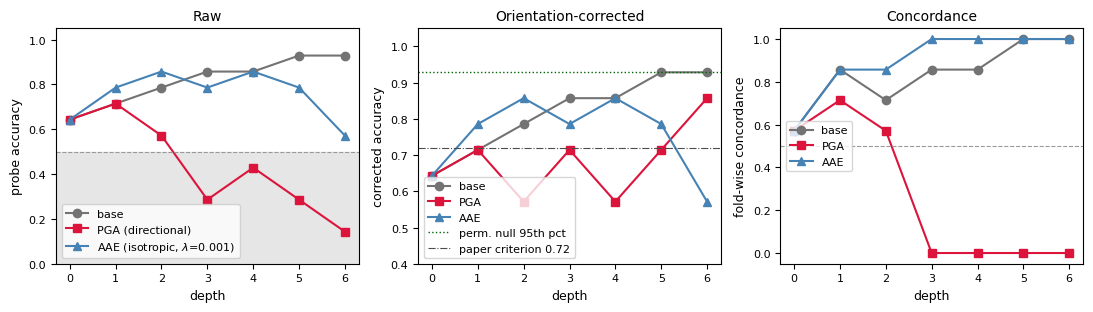

saved fig_aae_vs_pga_70m.{png,pdf} at 600 dpi


In [27]:
# ---- Figure (600 dpi, from the arrays computed above) ----
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'savefig.dpi': 600, 'font.size': 9, 'axes.titlesize': 10,
                            'axes.labelsize': 9, 'legend.fontsize': 8,
                            'xtick.labelsize': 8, 'ytick.labelsize': 8})
xs = list(range(N_DEPTHS))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

axes[0].plot(xs, base_probe, marker='o', color='0.45', label='base')
axes[0].plot(xs, pga_probe, marker='s', color='crimson', label='PGA (directional)')
axes[0].plot(xs, AAE['raw'], marker='^', color='steelblue', label=f'AAE (isotropic, $\\lambda$={MATCH_LAM:g})')
axes[0].axhline(0.5, color='0.6', lw=0.8, ls='--')
axes[0].axhspan(0.0, 0.5, color='0.9', zorder=0)
axes[0].set_ylim(0, 1.05); axes[0].set_xlabel('depth'); axes[0].set_ylabel('probe accuracy')
axes[0].set_title('Raw'); axes[0].legend(loc='lower left')

axes[1].plot(xs, [corrected(v) for v in base_probe], marker='o', color='0.45', label='base')
axes[1].plot(xs, [corrected(v) for v in pga_probe], marker='s', color='crimson', label='PGA')
axes[1].plot(xs, AAE['corrected'], marker='^', color='steelblue', label='AAE')
axes[1].axhline(NULL_P95, color='darkgreen', lw=1.0, ls=':', label='perm. null 95th pct')
axes[1].axhline(0.72, color='0.3', lw=0.8, ls='-.', label='paper criterion 0.72')
axes[1].set_ylim(0.4, 1.05); axes[1].set_xlabel('depth')
axes[1].set_ylabel('corrected accuracy')
axes[1].set_title('Orientation-corrected'); axes[1].legend(loc='lower left')

axes[2].plot(xs, base_conc, marker='o', color='0.45', label='base')
axes[2].plot(xs, pga_conc, marker='s', color='crimson', label='PGA')
axes[2].plot(xs, AAE['concordance'], marker='^', color='steelblue', label='AAE')
axes[2].axhline(0.5, color='0.6', lw=0.8, ls='--')
axes[2].set_ylim(-0.05, 1.05); axes[2].set_xlabel('depth')
axes[2].set_ylabel('fold-wise concordance')
axes[2].set_title('Concordance'); axes[2].legend(loc='center left')

plt.tight_layout()
for ext in ('png', 'pdf'):
    plt.savefig(os.path.join(OUT, f'fig_aae_vs_pga_70m.{ext}'), dpi=600, bbox_inches='tight')
plt.show()
print('saved fig_aae_vs_pga_70m.{png,pdf} at 600 dpi')


## Reporting rules for this notebook

The middle panel is the one that decides the paper's design claim. Read the raw panel alone and
whichever method dips further looks better; that reading is the error this experiment exists to
prevent. The corrected panel is the accuracy actually available to an attacker, and the
concordance panel distinguishes the two ways a raw accuracy can be low: near 0.5 concordance is
non-information, near 0 is a systematically inverted rule.

Report whichever ordering the run produces. If the isotropic ablation matches or beats the
directional objective at matched recall, the paper must say so, because the directional
objective is the paper's method contribution and the comparison is the test of it. If the
comparison fails to match recall within the stated tolerance, no probe-side conclusion follows
and the run must be repeated over a wider lambda grid before anything is written down.

The permutation null is a lower bound: it maximises over layers but not over the probe suite,
whereas the fresh-suite worst case maximises over both. A fresh-suite worst case that merely
exceeds this null is therefore weak evidence, and should be described as such rather than as a
successful attack.
